# 03 — Knowledge Base and Learning

**Source:** `tutorials/3-knowledgebase_and_learning.ipynb`

The previous notebooks introduced LTN symbols in isolation.
Here we build a complete learning system: a **knowledge base** of axioms,
a training loop that maximises satisfaction, and a visualisation of what the model learned.

**What is new here compared to notebook 01:**
- A predicate that takes **both a data point and a class label** as inputs
- A **softmax** output to enforce mutual exclusivity between classes
- The `Equiv` (↔) connective
- The `@tf.function` decorator and why you need it
- The pattern for **batched training** (mini-batches from a dataset)

**The problem:** 19 points in [0,4]×[0,4]. Two are labelled (one class A, one class B).
The rest are unlabelled. We know: A and B are mutually exclusive, and nearby points
share the same class. Can the model learn to classify all points from just two labels
and those two rules?

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import ltn

## 1. The domain: 2D points

We have 19 points, two of which are labelled.
`point_a` is a known class-A individual, `point_b` is a known class-B individual.
All others are unlabelled. Therefore,  the model must infer their class from the rules.

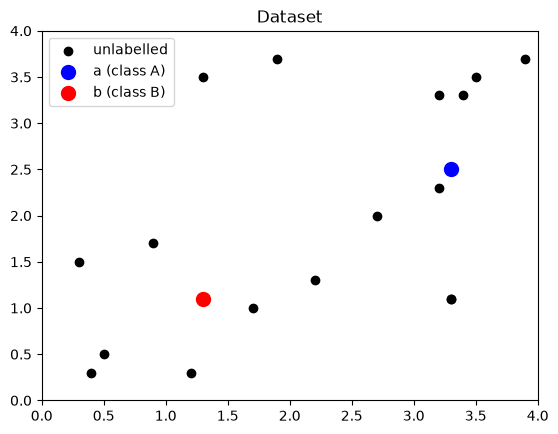

In [2]:
points = np.array([
    [0.4,0.3],[1.2,0.3],[2.2,1.3],[1.7,1.0],[0.5,0.5],[0.3,1.5],[1.3,1.1],[0.9,1.7],
    [3.4,3.3],[3.2,3.3],[3.2,2.3],[2.7,2.0],[3.5,3.5],[3.3,2.5],[3.3,1.1],[1.9,3.7],
    [1.3,3.5],[3.3,1.1],[3.9,3.7]
])
point_a = [3.3, 2.5]   # known class A
point_b = [1.3, 1.1]   # known class B

fig, ax = plt.subplots()
ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.scatter(points[:,0], points[:,1], color="black", label="unlabelled")
ax.scatter(*point_a, color="blue",  label="a (class A)", s=100, zorder=5)
ax.scatter(*point_b, color="red",   label="b (class B)", s=100, zorder=5)
ax.set_title("Dataset"); plt.legend(); plt.show()

## 2. The predicate C(x, l),  a classifier with label input

The predicate `C(x, l)` answers: *"does point x belong to class l?"*

Notice it takes **two inputs**: the point `x` and a one-hot label `l`.
This is a different design from notebook 01 where we had separate `Smokes(x)`, `Cancer(x)`.
Here a single predicate handles all classes by conditioning on the label.

In [3]:
class ModelC(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(5, activation=tf.nn.elu)
        self.dense2 = tf.keras.layers.Dense(5, activation=tf.nn.elu)
        self.dense3 = tf.keras.layers.Dense(2, activation=tf.nn.softmax)  # 2 classes

    def call(self, inputs):
        x, label = inputs[0], inputs[1]   # point and one-hot label
        x = self.dense1(x)
        x = self.dense2(x)
        prob = self.dense3(x)              # softmax → (prob_A, prob_B), sum=1
        return tf.math.reduce_sum(prob * label, axis=1)  # pick the prob for the queried class

C = ltn.Predicate(ModelC())

---
### ❓ Q — Why does C take the label l as input instead of just the point x?

**Design choice: one predicate for all classes vs one predicate per class.**

In notebook 01 we had `Smokes(x)` and `Cancer(x)`, two separate predicates.
That works when the number of classes is small and fixed.

Here we use `C(x, l)`, a single predicate that takes a one-hot label as a second argument.
The internal model computes a softmax over all classes and then selects the probability
for the queried class using `reduce_sum(prob * label, axis=1)`.

**Why is this useful?**
- A single model shares parameters across all classes (more efficient)
- You can query any class with the same predicate: `C(x, l_a)`, `C(x, l_b)`, `C(x, l)`
- The variable `l` ranging over all one-hot labels lets you write axioms like
  `∀x,l C(x,l) ↔ C(x',l)` — "x and x' agree on every class at once"

**The tradeoff:** the model is slightly more complex internally, but axioms become
more concise because you quantify over labels rather than writing one rule per class.

---
### ❓ Q — Why softmax instead of sigmoid?

**Sigmoid** outputs an independent value in [0,1] per class — classes can all be
high or all be low simultaneously. It does not enforce mutual exclusivity.

**Softmax** outputs a probability distribution: values in [0,1] that **sum to 1**.
If class A has probability 0.9, class B must have probability 0.1.
Mutual exclusivity is baked into the architecture.

In this problem we know A and B are mutually exclusive, so softmax is the right choice.
The LTN axioms reinforce this further through the logical KB, but the architecture
already encodes it as a hard constraint.

## 3. Variables, constants, and the Sim predicate

In [4]:
# Variables ranging over all points (used in the universal rule)
x1 = ltn.Variable("x1", points)
x2 = ltn.Variable("x2", points)

# The two labelled individuals (non-trainable — their positions are fixed data)
a = ltn.Constant([3.3, 2.5], trainable=False)
b = ltn.Constant([1.3, 1.1], trainable=False)

# One-hot label constants
l_a = ltn.Constant([1, 0], trainable=False)   # class A
l_b = ltn.Constant([0, 1], trainable=False)   # class B

# Variable ranging over all possible labels (for the universal rule)
l = ltn.Variable("l", [[1, 0], [0, 1]])        # two individuals: l_a and l_b

# Sim(x1, x2) = exp(-‖x1 - x2‖) high when points are close, low when far
Sim = ltn.Predicate.Lambda(
    lambda args: tf.exp(-tf.sqrt(tf.reduce_sum(tf.square(args[0] - args[1]), axis=1)))
)

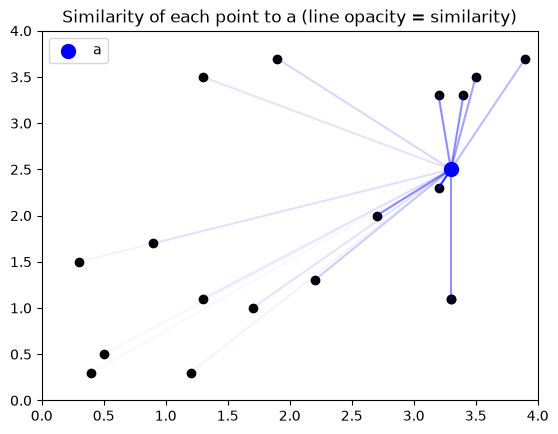

In [5]:
# Visualise the similarity of each point to 'a'
sims = Sim([x1, a]).tensor.numpy()

fig, ax = plt.subplots()
ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.scatter(points[:,0], points[:,1], color="black")
ax.scatter(*point_a, color="blue", s=100, zorder=5, label="a")
ax.set_title("Similarity of each point to a (line opacity = similarity)")
for i, s in enumerate(sims):
    ax.plot([points[i,0], point_a[0]], [points[i,1], point_a[1]],
            alpha=float(s), color="blue")
plt.legend(); plt.show()

## 4. Connectives — introducing Equiv (↔)

The rule "nearby points share the same label" is written as:

$$\forall x_1, x_2, l \; \big(\mathrm{Sim}(x_1,x_2) \rightarrow (C(x_1,l) \leftrightarrow C(x_2,l))\big)$$

The new connective here is **Equiv** (↔ biconditional / if and only if).
In fuzzy logic it is simply: $(p \rightarrow q) \land (q \rightarrow p)$.

In [6]:
Not    = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And    = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Or     = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())
Equiv  = ltn.Wrapper_Connective(ltn.fuzzy_ops.Equiv(
    ltn.fuzzy_ops.And_Prod(),
    ltn.fuzzy_ops.Implies_Reichenbach()
))

Forall = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=2), semantics="forall")
formula_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMeanError(p=2))

---
### ❓ Q — Why is Equiv not a primitive like And or Implies?

Because in fuzzy logic there is no unique way to define biconditional (it depends on which t-norm and implication you are using).
`ltn.fuzzy_ops.Equiv` takes your chosen `And` and `Implies` operators
and composes them: `Equiv(p, q) = And(Implies(p,q), Implies(q,p))`.

This means the fuzzy value of `p ↔ q` is high only when both `p→q` and `q→p` are high,
i.e. when p and q are close to the same truth value.

## 5. The knowledge base

Three axioms:
1. `C(a, l_a)` — point a belongs to class A
2. `C(b, l_b)` — point b belongs to class B
3. `∀x₁,x₂,l  Sim(x₁,x₂) → (C(x₁,l) ↔ C(x₂,l))` — nearby points share all labels

In [7]:
@tf.function
def axioms():
    ax = [
        C([a, l_a]),                          # axiom 1: a is class A
        C([b, l_b]),                          # axiom 2: b is class B
        Forall(                               # axiom 3: similarity rule
            [x1, x2, l],
            Implies(
                Sim([x1, x2]),
                Equiv(C([x1, l]), C([x2, l]))
            )
        )
    ]
    return formula_aggregator(ax).tensor

# IMPORTANT: run once before training to initialise weights and compile the graph
print("Initial sat level: %.4f" % axioms().numpy())

Initial sat level: 0.6661


---
### ❓ Q — What does @tf.function do? Why is it needed?

Without `@tf.function`, Python executes TensorFlow operations **eagerly**,
one operation at a time, interpreted line by line. This is easy to debug but slow.

`@tf.function` tells TensorFlow to **trace** the function on the first call and
compile it into a static computation graph (called a *TF graph*). Subsequent calls
execute the pre-compiled graph directly, bypassing Python. it's much faster.

**The first call is special:** TensorFlow traces the function, builds the graph,
and initialises any uninitialised weights (like the MLP layers). That is why the
tutorial says to always call `axioms()` once before training. if you skip it,
the first training step does the tracing, which can cause subtle issues with
gradient tracking.

**Practical rule:** put your KB formula inside `@tf.function`. Do not put the
training loop itself inside it, the tape and optimizer calls need Python control flow.

## 6. Training loop

Same structure as notebook 01: minimise `1 - sat`.
Here only the MLP weights of `C` are trainable, the points, labels, and Sim are all fixed.

In [8]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
trainable_variables = C.trainable_variables

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = 1. - axioms()
    grads = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(grads, trainable_variables))
    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d}  sat={axioms().numpy():.4f}")

print(f"Final sat: {axioms().numpy():.4f}")

Epoch    0  sat=0.6679
Epoch  400  sat=0.9469
Epoch  800  sat=0.9536
Epoch 1200  sat=0.9547
Epoch 1600  sat=0.9550
Final sat: 0.9550


## 7. Visualising the result

After training we query `C(x, l_a)` and `C(x, l_b)` for every point.
The colour shows how strongly the model assigns each class.

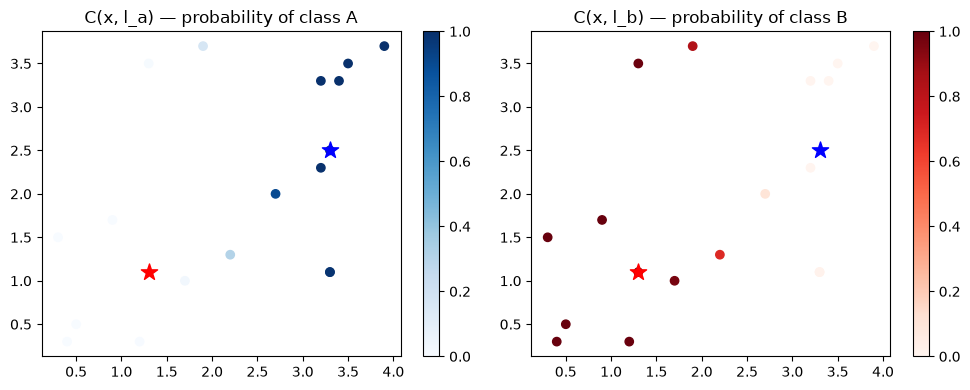

Note: from just 2 labels and 1 rule, the model learned to cluster the points.


In [9]:
is_a = C([x1, l_a]).tensor.numpy()
is_b = C([x1, l_b]).tensor.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sc1 = ax1.scatter(points[:,0], points[:,1], c=is_a, vmin=0, vmax=1, cmap="Blues")
ax1.scatter(*point_a, color="blue",  s=150, marker="*", zorder=5, label="a")
ax1.scatter(*point_b, color="red",   s=150, marker="*", zorder=5, label="b")
ax1.set_title("C(x, l_a) — probability of class A"); plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(points[:,0], points[:,1], c=is_b, vmin=0, vmax=1, cmap="Reds")
ax2.scatter(*point_a, color="blue",  s=150, marker="*", zorder=5, label="a")
ax2.scatter(*point_b, color="red",   s=150, marker="*", zorder=5, label="b")
ax2.set_title("C(x, l_b) — probability of class B"); plt.colorbar(sc2, ax=ax2)

plt.tight_layout(); plt.show()
print("Note: from just 2 labels and 1 rule, the model learned to cluster the points.")

## 8. Special case: batched training

So far all variables were built **once** from the full dataset.
In real ML problems the dataset is too large to fit in one batch.
The pattern changes: pass the current batch as arguments to the KB function
and create variables **inside** the function.

In [ ]:
# Pattern for batched training — not run here, shown for reference

@tf.function
def axioms_batched(batch_x1, batch_x2):
    # Variables are created fresh each call with the current batch
    bx1 = ltn.Variable("x1", batch_x1)
    bx2 = ltn.Variable("x2", batch_x2)
    ax = [
        C([a, l_a]),
        C([b, l_b]),
        Forall([bx1, bx2, l], Implies(Sim([bx1, bx2]), Equiv(C([bx1, l]), C([bx2, l]))))
    ]
    return formula_aggregator(ax).tensor

# Pseudocode training loop:
# for epoch in range(epochs):
#     for batch_x1, batch_x2 in dataloader:
#         with tf.GradientTape() as tape:
#             loss = 1. - axioms_batched(batch_x1, batch_x2)
#         grads = tape.gradient(loss, trainable_variables)
#         optimizer.apply_gradients(zip(grads, trainable_variables))

print("Pattern shown — variables created inside @tf.function receive the batch each step.")

---
### ❓ Q — Why create variables inside the function for batched training?

Two reasons:

**1. Fresh data each step.**
The variable is a wrapper around a tensor of individuals. If you create it outside,
it is fixed to the first batch forever. Creating it inside means it is rebuilt
with the current batch tensor on every call.

**2. Gradient tracking for trainable constants.**
If your variables are built from trainable constants (embeddings), the GradientTape
must see the construction of the variable inside its scope. Since `@tf.function`
is called inside the `with GradientTape()` block, creating the variable inside
the function satisfies this requirement automatically.

This is the same rule from notebook 02 section 6, just packaged as the standard
batched training pattern.

## Summary

| Concept | Key point                                                                             |
|---------|---------------------------------------------------------------------------------------|
| `C(x, l)`  label as input | One predicate for all classes; softmax enforces mutual exclusivity                    |
| `Equiv(p, q)` | `And(Implies(p,q), Implies(q,p))`  built from your chosen And and Implies             |
| `@tf.function` | Compiles KB to a TF graph; first call initialises weights, always run before training |
| `formula_aggregator` | Folds multiple axiom truth values into one sat score (same pMeanError fold)           |
| Batched training | Create variables inside the KB function; pass batch as argument                       |
| Semi-supervised learning | Two labelled points + one rule → full classification of 19 points                     |

**Next:** A sudoku solver that combines CNNs and reasoning